<a href="https://colab.research.google.com/github/beyzaturku/2209/blob/main/yolo_models/yolo6_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
!pip install ultralytics

In [24]:
import torch
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [28]:
def train_yolo():
    model = YOLO('yolov6n.yaml')

    results = model.train(
        data='/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml',
        epochs=50,
        imgsz=640,
        batch=16,
        project="/content/drive/MyDrive/altitude/high_alt_object_detection/yolo6_train",
        name="yolov6",
        save=True,
        save_period=5,
        val=True
    )
    return model, results

In [26]:
def create_metrics_table(csv_path):
    # CSV dosyasını oku
    df = pd.read_csv(csv_path)

    # Önemli sütunları seç ve yeniden adlandır
    metrics_df = df[['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                     'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                     'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']].copy()

    # Sütun isimlerini sadeleştir
    metrics_df.columns = ['Epoch', 'Train_Box_Loss', 'Train_Cls_Loss', 'Train_DFL_Loss',
                         'Precision', 'Recall', 'mAP50', 'mAP50_95',
                         'Val_Box_Loss', 'Val_Cls_Loss', 'Val_DFL_Loss']

    print("Model Performans Metrikleri:")
    print(metrics_df.tail(10))  # Son 10 epoch
    return metrics_df

def visualize_results(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss grafikleri (Train vs Val)
    axes[0,0].plot(df['Epoch'], df['Train_Box_Loss'], label='Train Box Loss', color='blue')
    axes[0,0].plot(df['Epoch'], df['Val_Box_Loss'], label='Val Box Loss', color='red')
    axes[0,0].set_title('Box Loss Eğrileri')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)

    # mAP grafikleri
    axes[0,1].plot(df['Epoch'], df['mAP50'], label='mAP50', color='green')
    axes[0,1].plot(df['Epoch'], df['mAP50_95'], label='mAP50-95', color='orange')
    axes[0,1].set_title('mAP Metrikleri')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('mAP')
    axes[0,1].legend()
    axes[0,1].grid(True)

    # Precision ve Recall
    axes[1,0].plot(df['Epoch'], df['Precision'], label='Precision', color='purple')
    axes[1,0].plot(df['Epoch'], df['Recall'], label='Recall', color='brown')
    axes[1,0].set_title('Precision & Recall')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Değer')
    axes[1,0].legend()
    axes[1,0].grid(True)

    # Tüm Loss türleri
    axes[1,1].plot(df['Epoch'], df['Train_Box_Loss'], label='Box Loss')
    axes[1,1].plot(df['Epoch'], df['Train_Cls_Loss'], label='Cls Loss')
    axes[1,1].plot(df['Epoch'], df['Train_DFL_Loss'], label='DFL Loss')
    axes[1,1].set_title('Eğitim Loss Türleri')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Loss')
    axes[1,1].legend()
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()

    # Son epoch özet tablosu
    final_metrics = df.iloc[-1]
    print(f"\nFinal Epoch ({int(final_metrics['Epoch'])}) Sonuçları:")
    print(f"mAP50: {final_metrics['mAP50']:.4f}")
    print(f"mAP50-95: {final_metrics['mAP50_95']:.4f}")
    print(f"Precision: {final_metrics['Precision']:.4f}")
    print(f"Recall: {final_metrics['Recall']:.4f}")

def test_single_image(model_path, image_path, conf_threshold=0.25, iou_threshold=0.45):
    model = YOLO(model_path)

    # Düşük threshold ile tahmin (daha fazla tespit için)
    results = model(image_path, conf=conf_threshold, iou=iou_threshold)

    # Görselleştirme
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Sonuçları çiz
    annotated_img = results[0].plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img)
    plt.title(f'YOLO Tespiti (conf≥{conf_threshold}, iou≥{iou_threshold}) - {len(results[0].boxes) if results[0].boxes is not None else 0} nesne bulundu')
    plt.axis('off')
    plt.show()

    # Detay bilgiler
    if results[0].boxes is not None:
        print(f"\nToplam {len(results[0].boxes)} nesne tespit edildi:")
        print("-" * 40)
        for i, box in enumerate(results[0].boxes):
            conf = box.conf.item()
            cls = int(box.cls.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            print(f"Nesne {i+1}: Sınıf {cls}, Güven: {conf:.3f}, Box: [{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")
    else:
        print("Hiç nesne tespit edilmedi!")

    return results

def compare_thresholds(model_path, image_path):
    """Farklı confidence ve IOU threshold'larını karşılaştır"""
    thresholds = [
        (0.5, 0.5),   # Varsayılan (yüksek)
        (0.3, 0.4),   # Orta
        (0.1, 0.3)    # Düşük (daha hassas)
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (conf, iou) in enumerate(thresholds):
        model = YOLO(model_path)
        results = model(image_path, conf=conf, iou=iou)

        annotated_img = results[0].plot()

        axes[i].imshow(annotated_img)
        axes[i].set_title(f'conf={conf}, iou={iou}\n{len(results[0].boxes) if results[0].boxes is not None else 0} tespit')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [29]:
import torch
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import cv2

print("1. Model eğitimi başlatılıyor...")
model, results = train_yolo()

1. Model eğitimi başlatılıyor...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov6n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov6, nbs=64, nms=False, opset=None, optimize=False, opt

train: Scanning /content/drive/MyDrive/altitude/high_alt_object_detection/dataset/labels/train.cache... 281 images, 0 backgrounds, 0 corrupt: 100%|██████████| 281/281 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.7±0.5 ms, read: 16.5±4.3 MB/s, size: 40.4 KB)


val: Scanning /content/drive/MyDrive/altitude/high_alt_object_detection/dataset/labels/val.cache... 71 images, 0 backgrounds, 0 corrupt: 100%|██████████| 71/71 [00:00<?, ?it/s]


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      50/50      1.91G      1.644      1.098     0.8992        115        640: 100%|██████████| 18/18 [00:01<00:00, 11.38it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  7.59it/s]


                   all         71        925      0.929       0.85      0.923      0.618

50 epochs completed in 0.033 hours.
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo6_train/yolov6/weights/last.pt, 8.7MB
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo6_train/yolov6/weights/best.pt, 8.7MB

Validating /content/drive/MyDrive/altitude/high_alt_object_detection/yolo6_train/yolov6/weights/best.pt...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv6n summary (fused): 68 layers, 4,234,140 parameters, 0 gradients, 11.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.77it/s]


                   all         71        925      0.933      0.809      0.916      0.622
                   car         71        912      0.967      0.618      0.836      0.425
                   bus         13         13      0.899          1      0.995      0.819
Speed: 0.1ms preprocess, 0.4ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/drive/MyDrive/altitude/high_alt_object_detection/yolo6_train/yolov6



2. CSV'den metrikler okunuyor...
Model Performans Metrikleri:
    Epoch  Train_Box_Loss  Train_Cls_Loss  Train_DFL_Loss  Precision   Recall  \
40     41         1.86305         1.26704         0.92020    0.73630  0.81517   
41     42         1.76585         1.19711         0.91842    0.93436  0.80866   
42     43         1.75327         1.16808         0.91211    0.90313  0.81050   
43     44         1.73032         1.15894         0.90589    0.86021  0.84205   
44     45         1.70886         1.14640         0.91304    0.92726  0.85584   
45     46         1.68149         1.12471         0.90903    0.92262  0.82401   
46     47         1.70526         1.13086         0.91213    0.93231  0.83662   
47     48         1.66765         1.08359         0.90926    0.88201  0.83688   
48     49         1.67499         1.10469         0.90649    0.91890  0.82981   
49     50         1.64379         1.09752         0.89919    0.92911  0.85013   

      mAP50  mAP50_95  Val_Box_Loss  Val_Cls_

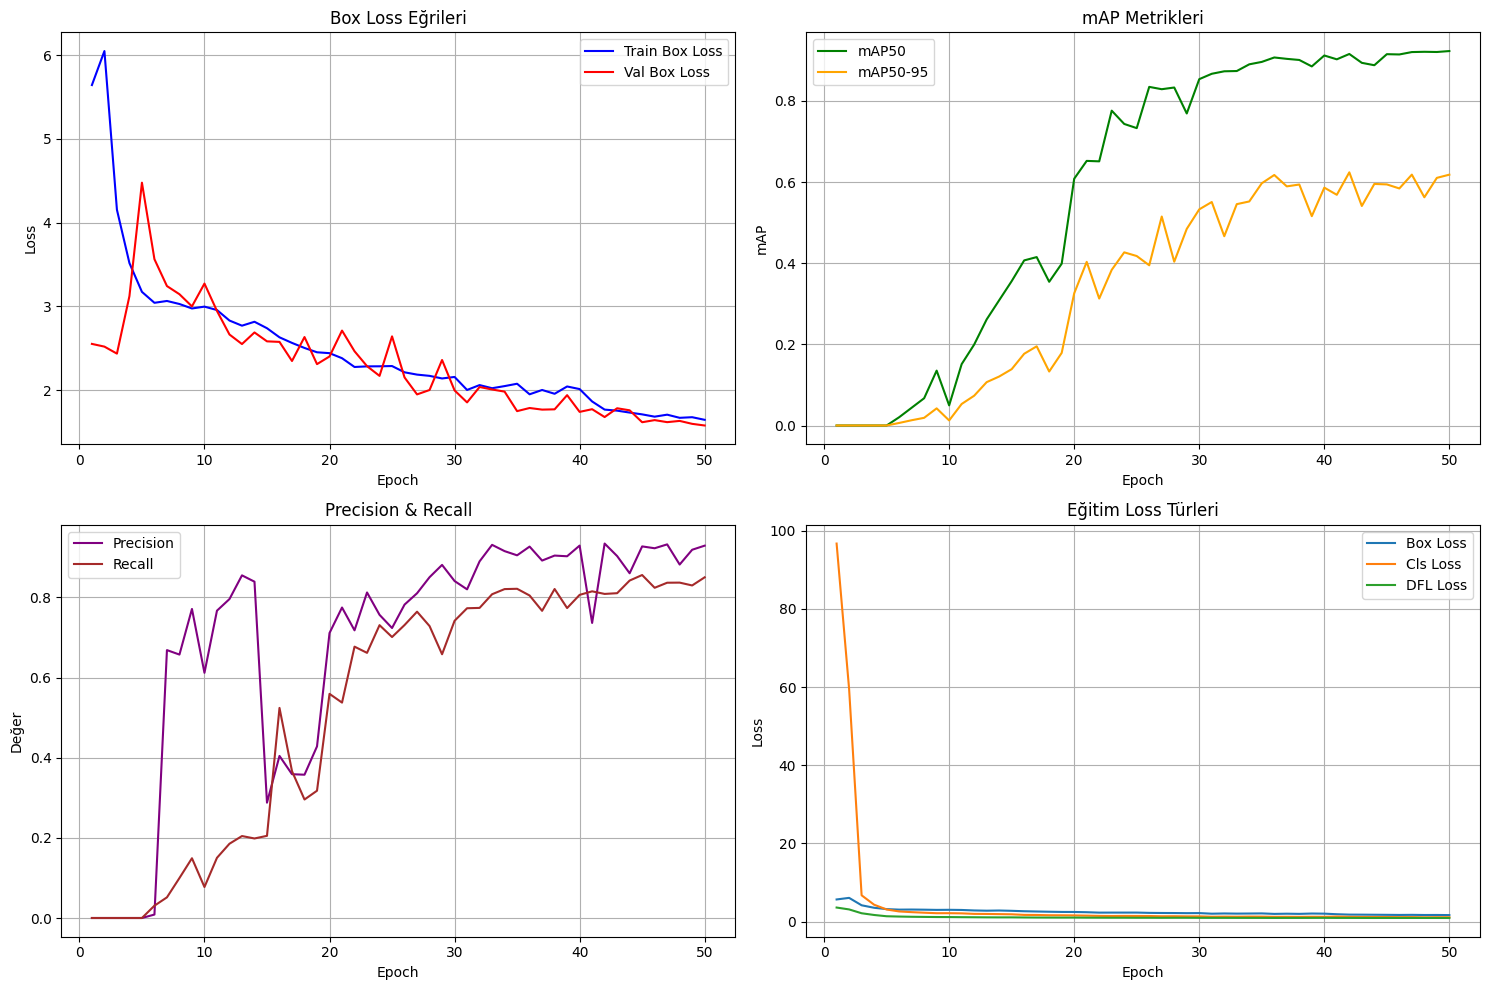


Final Epoch (50) Sonuçları:
mAP50: 0.9231
mAP50-95: 0.6183
Precision: 0.9291
Recall: 0.8501

4. Tek görsel test ediliyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 3 cars, 29.6ms
Speed: 2.1ms preprocess, 29.6ms inference, 2.0ms postprocess per image at shape (1, 3, 352, 640)


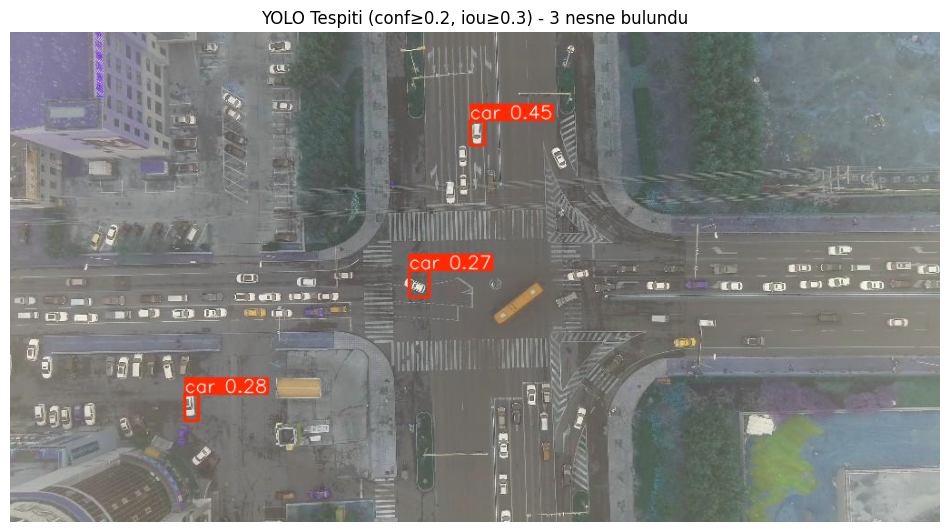


Toplam 3 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.449, Box: [507,99,522,126]
Nesne 2: Sınıf 0, Güven: 0.279, Box: [192,400,207,428]
Nesne 3: Sınıf 0, Güven: 0.267, Box: [440,264,462,293]

4. Farklı threshold'lar karşılaştırılıyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 (no detections), 7.4ms
Speed: 2.2ms preprocess, 7.4ms inference, 0.8ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 1 car, 8.1ms
Speed: 2.2ms preprocess, 8.1ms inference, 2.0ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 6 cars, 7.5ms
Speed: 1.9ms preprocess, 7.5ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)

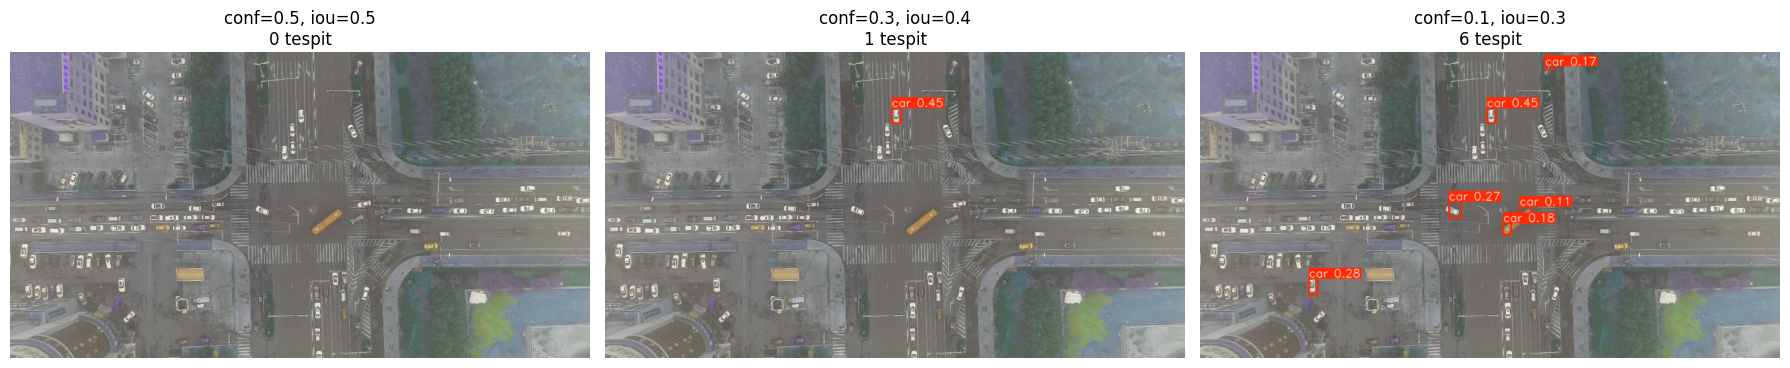

In [32]:
print("\n2. CSV'den metrikler okunuyor...")
df = create_metrics_table('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo6_train/yolov6/results.csv')

    # Görselleştir
print("\n3. Sonuçlar görselleştiriliyor...")
visualize_results(df)

    # Test et
print("\n4. Tek görsel test ediliyor...")
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo6_train/yolov6/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.2, iou_threshold=0.3)

print("\n4. Farklı threshold'lar karşılaştırılıyor...")
compare_thresholds('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo6_train/yolov6/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg')


image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 6 cars, 7.5ms
Speed: 2.0ms preprocess, 7.5ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)


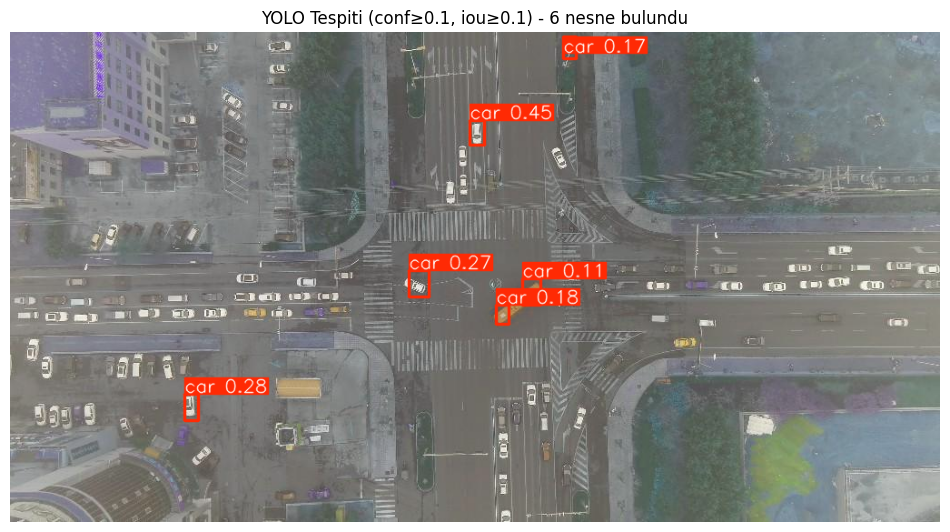


Toplam 6 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.449, Box: [507,99,522,126]
Nesne 2: Sınıf 0, Güven: 0.279, Box: [192,400,207,428]
Nesne 3: Sınıf 0, Güven: 0.267, Box: [440,264,462,293]
Nesne 4: Sınıf 0, Güven: 0.180, Box: [536,302,549,322]
Nesne 5: Sınıf 0, Güven: 0.174, Box: [609,6,624,31]
Nesne 6: Sınıf 0, Güven: 0.107, Box: [565,273,585,302]


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'vehicle', 2: 'truck', 3: 'bus'}
 obb: None
 orig_img: array([[[130, 124, 155],
         [130, 124, 155],
         [131, 125, 156],
         ...,
         [130, 146, 158],
         [136, 152, 164],
         [142, 158, 170]],
 
        [[133, 127, 158],
         [133, 127, 158],
         [133, 127, 158],
         ...,
         [132, 148, 160],
         [136, 152, 164],
         [139, 155, 167]],
 
        [[136, 130, 161],
         [136, 130, 161],
         [135, 129, 160],
         ...,
         [134, 150, 162],
         [135, 151, 163],
         [136, 152, 164]],
 
        ...,
 
        [[139, 136, 131],
         [137, 134, 129],
         [134, 131, 126],
         ...,
         [134, 139, 130],
         [133, 138, 129],
         [133, 138, 129]],
 
        [[139, 136, 132],
         [136, 133, 129],
         [132, 129, 125],

In [33]:
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo6_train/yolov6/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.1, iou_threshold=0.1)


image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 90 cars, 12 trucks, 13 buss, 8.0ms
Speed: 2.0ms preprocess, 8.0ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)


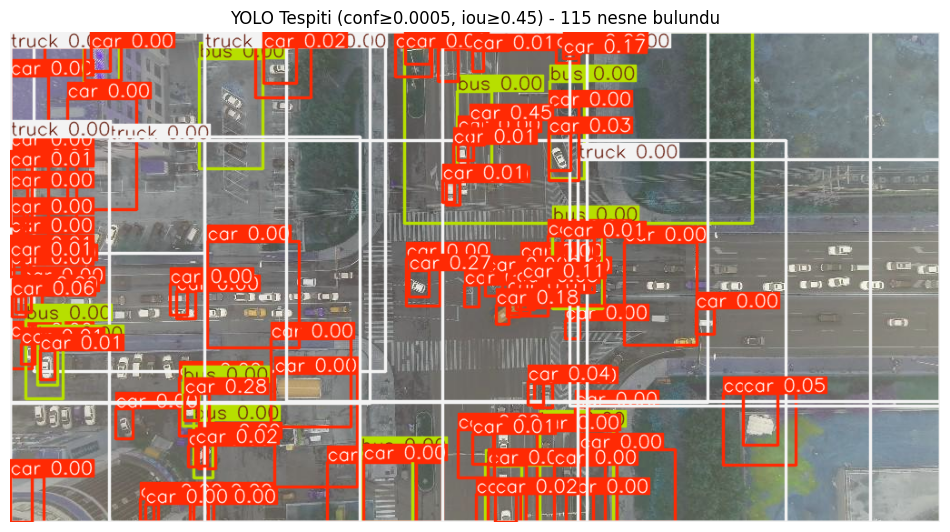


Toplam 115 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.449, Box: [507,99,522,126]
Nesne 2: Sınıf 0, Güven: 0.279, Box: [192,400,207,428]
Nesne 3: Sınıf 0, Güven: 0.267, Box: [440,264,462,293]
Nesne 4: Sınıf 0, Güven: 0.180, Box: [536,302,549,322]
Nesne 5: Sınıf 0, Güven: 0.174, Box: [609,6,624,31]
Nesne 6: Sınıf 0, Güven: 0.107, Box: [565,273,585,302]
Nesne 7: Sınıf 0, Güven: 0.056, Box: [2,292,18,314]
Nesne 8: Sınıf 0, Güven: 0.050, Box: [807,398,846,455]
Nesne 9: Sınıf 0, Güven: 0.040, Box: [571,385,588,411]
Nesne 10: Sınıf 0, Güven: 0.035, Box: [558,277,577,307]
Nesne 11: Sınıf 0, Güven: 0.030, Box: [594,112,617,154]
Nesne 12: Sınıf 0, Güven: 0.025, Box: [205,455,218,479]
Nesne 13: Sınıf 0, Güven: 0.016, Box: [280,0,316,58]
Nesne 14: Sınıf 0, Güven: 0.016, Box: [535,509,557,540]
Nesne 15: Sınıf 0, Güven: 0.014, Box: [477,164,489,188]
Nesne 16: Sınıf 0, Güven: 0.012, Box: [34,352,50,383]
Nesne 17: Sınıf 0, Güven: 0.011, Box: [488,124,505,

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'vehicle', 2: 'truck', 3: 'bus'}
 obb: None
 orig_img: array([[[130, 124, 155],
         [130, 124, 155],
         [131, 125, 156],
         ...,
         [130, 146, 158],
         [136, 152, 164],
         [142, 158, 170]],
 
        [[133, 127, 158],
         [133, 127, 158],
         [133, 127, 158],
         ...,
         [132, 148, 160],
         [136, 152, 164],
         [139, 155, 167]],
 
        [[136, 130, 161],
         [136, 130, 161],
         [135, 129, 160],
         ...,
         [134, 150, 162],
         [135, 151, 163],
         [136, 152, 164]],
 
        ...,
 
        [[139, 136, 131],
         [137, 134, 129],
         [134, 131, 126],
         ...,
         [134, 139, 130],
         [133, 138, 129],
         [133, 138, 129]],
 
        [[139, 136, 132],
         [136, 133, 129],
         [132, 129, 125],

In [45]:
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo6_train/yolov6/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.0005)